## Chris Dhong
## Group 3
## Group Assignment Task 3

In [1]:
from pyspark.sql import SparkSession
import csv
from typing import Iterable, Tuple
import matplotlib.pyplot as plt

In [ ]:
# Start Spark
spark = SparkSession.builder.appName("chris-jupyter-notebook").getOrCreate()
sc = spark.sparkContext
sc.setLogLevel("ERROR")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/02 19:28:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
import argparse

parser = argparse.ArgumentParser()
parser.add_argument(
    "--is-local",
    type=str,
    default="true",
    help="Whether running in local mode",
)

args, unknown = parser.parse_known_args()
is_local = args.is_local.lower() == "true"
if is_local:
    prefix = "../data/processed/chunks"
    num_csv_path = f"{prefix}/num_2020_chunk.csv"
    pre_csv_path = f"{prefix}/pre_2020_chunk.csv"
    sub_csv_path = f"{prefix}/sub_2020_chunk.csv"
    tag_csv_path = f"{prefix}/tag_2020_chunk.csv"
else:
    prefix = "gs://msds-694-cohort-14-3/data"
    num_csv_path = f"{prefix}/num_2020.csv"
    pre_csv_path = f"{prefix}/pre_2020.csv"
    sub_csv_path = f"{prefix}/sub_2020.csv"
    tag_csv_path = f"{prefix}/tag_2020.csv"

print(f"Is local environment: {is_local}")

print(f"Num CSV path: {num_csv_path}")
print(f"Pre CSV path: {pre_csv_path}")
print(f"Sub CSV path: {sub_csv_path}")
print(f"Tag CSV path: {tag_csv_path}")

num_rdd = sc.textFile(num_csv_path)
pre_rdd = sc.textFile(pre_csv_path)
sub_rdd = sc.textFile(sub_csv_path)
tag_rdd = sc.textFile(tag_csv_path)

# print size of each RDD
print(f"Num RDD size: {num_rdd.count()}")
print(f"Pre RDD size: {pre_rdd.count()}")
print(f"Sub RDD size: {sub_rdd.count()}")
print(f"Tag RDD size: {tag_rdd.count()}")

Is local environment: True
Num CSV path: ../data/processed/chunks/num_2020_chunk.csv
Pre CSV path: ../data/processed/chunks/pre_2020_chunk.csv
Sub CSV path: ../data/processed/chunks/sub_2020_chunk.csv
Tag CSV path: ../data/processed/chunks/tag_2020_chunk.csv


Num RDD size: 10001
Pre RDD size: 10001
Sub RDD size: 10001
Tag RDD size: 10001


In [ ]:
# Helpers to parse CSV RDDs into dictionaries


def parse_csv_rdd(rdd):
    header = next(csv.reader([rdd.first()]))

    def parse_partition(idx: int, iterator: Iterable[str]):
        reader = csv.reader(iterator)
        for row_idx, row in enumerate(reader):
            if idx == 0 and row_idx == 0:
                # Skip header only on the first partition
                continue
            yield row

    rows = rdd.mapPartitionsWithIndex(parse_partition)
    return header, rows


num_header, num_rows = parse_csv_rdd(num_rdd)
num_records = num_rows.map(lambda row: dict(zip(num_header, row)))

sub_header, sub_rows = parse_csv_rdd(sub_rdd)
sub_records = sub_rows.map(lambda row: dict(zip(sub_header, row)))

print("Parsed num rows:", num_records.count())
print("Parsed sub rows:", sub_records.count())

Parsed num rows: 10000
Parsed sub rows: 10000


In [ ]:
# Basic RDD-only profiling on the num file
TAG_COL = "tag"  # XBRL tag
COMPANY_COL = "adsh"  # filing ID (acts like entity/filing)
DATE_COL = "ddate"  # date in YYYYMMDD format

# Q1: Which tags appear most often in this subset?
tag_counts = (
    num_records.map(lambda d: (d.get(TAG_COL, ""), 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda kv: kv[1], ascending=False)
)

print("=== Q1: rows by tag (top 20) ===")
for tag, count in tag_counts.take(20):
    print(f"{tag}: {count}")

# Q2: How many unique filings, and which filings have the most rows?
q2_unique = (
    num_records.map(lambda d: d.get(COMPANY_COL, ""))
    .filter(lambda x: x != "")
    .distinct()
    .count()
)
print(f"\n=== Q2: unique filings (adsh) ===\nUnique IDs: {q2_unique}")

q2_top = (
    num_records.map(lambda d: (d.get(COMPANY_COL, ""), 1))
    .reduceByKey(lambda a, b: a + b)
    .filter(lambda kv: kv[0] != "")
    .sortBy(lambda kv: kv[1], ascending=False)
)

print("\nTop filings by number of rows (top 20):")
for adsh, count in q2_top.take(20):
    print(f"{adsh}: {count}")


# Q3: How many rows per year (using ddate)?
def extract_year(date_str: str):
    if not date_str:
        return None
    return date_str[:4] if len(date_str) >= 4 else None


q3 = (
    num_records.map(lambda d: extract_year(d.get(DATE_COL, "")))
    .filter(lambda year: year is not None)
    .map(lambda year: (year, 1))
    .reduceByKey(lambda a, b: a + b)
    .sortByKey()
)

print("\n=== Q3: rows per year ===")
for year, count in q3.collect():
    print(f"{year}: {count}")

=== Q1: rows by tag (top 20) ===
RevenueFromContractWithCustomerExcludingAssessedTax: 277
StockholdersEquity: 252
StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest: 206
NetIncomeLoss: 191
Revenues: 164
Assets: 146
OperatingIncomeLoss: 124
IncomeTaxExpenseBenefit: 113
ProfitLoss: 110
Goodwill: 90
EarningsPerShareDiluted: 84
EarningsPerShareBasic: 73
AdjustmentsToAdditionalPaidInCapitalSharebasedCompensationRequisiteServicePeriodRecognitionValue: 72
OtherComprehensiveIncomeLossNetOfTax: 72
NetCashProvidedByUsedInOperatingActivities: 72
ComprehensiveIncomeNetOfTax: 70
RevenueFromContractWithCustomerIncludingAssessedTax: 69
PropertyPlantAndEquipmentNet: 68
NetCashProvidedByUsedInFinancingActivities: 68
AvailableForSaleSecuritiesDebtSecurities: 63

=== Q2: unique filings (adsh) ===
Unique IDs: 4202

Top filings by number of rows (top 20):
0001193125-20-047353: 26
0000913778-20-000003: 19
0001654954-20-002485: 16
0001213900-20-007917: 16
0000930413-20-000859: 15
00011931

In [ ]:
# Additional RDD-only analysis on the submission (sub) file
IPO_FORMS = {"S-1", "S-1/A", "F-1", "F-1/A", "424B3", "424B4", "424B5"}
QUARTER_ORDER = {"q1": 1, "q2": 2, "q3": 3, "q4": 4}


def safe_int(value):
    try:
        return int(float(value))
    except (TypeError, ValueError):
        return None


def normalize_quarter(record):
    year = safe_int(record.get("year"))
    quarter_raw = (record.get("quarter") or record.get("fp") or "").lower()
    quarter = quarter_raw if quarter_raw in QUARTER_ORDER else None
    return year, quarter


def earlier_quarter(a: Tuple[int, str], b: Tuple[int, str]):
    if a[0] is None:
        return b
    if b[0] is None:
        return a
    rank_a = (a[0], QUARTER_ORDER.get(a[1], 0))
    rank_b = (b[0], QUARTER_ORDER.get(b[1], 0))
    return a if rank_a <= rank_b else b


# Unique company-quarter combinations across all filings
company_quarters = (
    sub_records.map(lambda d: (d.get("cik"), normalize_quarter(d)))
    .filter(lambda kv: kv[0] and kv[1][0] is not None and kv[1][1] is not None)
    .distinct()
)

# 1) Companies that filed IPO-related forms per quarter (unique CIKs)
ipo_counts = (
    sub_records.filter(lambda d: (d.get("form") or "").upper() in IPO_FORMS)
    .map(lambda d: (normalize_quarter(d), d.get("cik")))
    .filter(lambda kv: kv[0][0] is not None and kv[0][1] is not None and kv[1])
    .map(lambda kv: (kv[0], kv[1]))
    .distinct()
    .map(lambda kv: (kv[0], 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda kv: (kv[0][0], QUARTER_ORDER[kv[0][1]]))
)

print("=== Companies with IPO-related filings per quarter (unique CIKs) ===")
for (year, quarter), count in ipo_counts.collect():
    print(f"{year} {quarter}: {count}")

# 2) New reporting companies per quarter compared to all prior quarters
company_first_quarter = company_quarters.reduceByKey(
    lambda a, b: earlier_quarter(a, b)
)

new_companies = (
    company_quarters.join(company_first_quarter)
    .filter(lambda kv: kv[1][0] == kv[1][1])
    .map(lambda kv: (kv[1][0], kv[0]))
    .distinct()
)

new_counts = (
    new_companies.map(lambda kv: (kv[0], 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda kv: (kv[0][0], QUARTER_ORDER[kv[0][1]]))
)

all_reporting_counts = (
    company_quarters.map(lambda kv: (kv[1], 1))
    .reduceByKey(lambda a, b: a + b)
    .sortBy(lambda kv: (kv[0][0], QUARTER_ORDER[kv[0][1]]))
)

print("\n=== Unique reporting companies per quarter ===")
for (year, quarter), count in all_reporting_counts.collect():
    print(f"{year} {quarter}: {count}")

print("\n=== New reporting companies per quarter ===")
for (year, quarter), count in new_counts.collect():
    print(f"{year} {quarter}: {count}")

=== Companies with IPO-related filings per quarter (unique CIKs) ===
2020 q1: 66
2020 q2: 55

=== Unique reporting companies per quarter ===
2020 q1: 5404
2020 q2: 3701

=== New reporting companies per quarter ===
2020 q1: 5404
2020 q2: 737


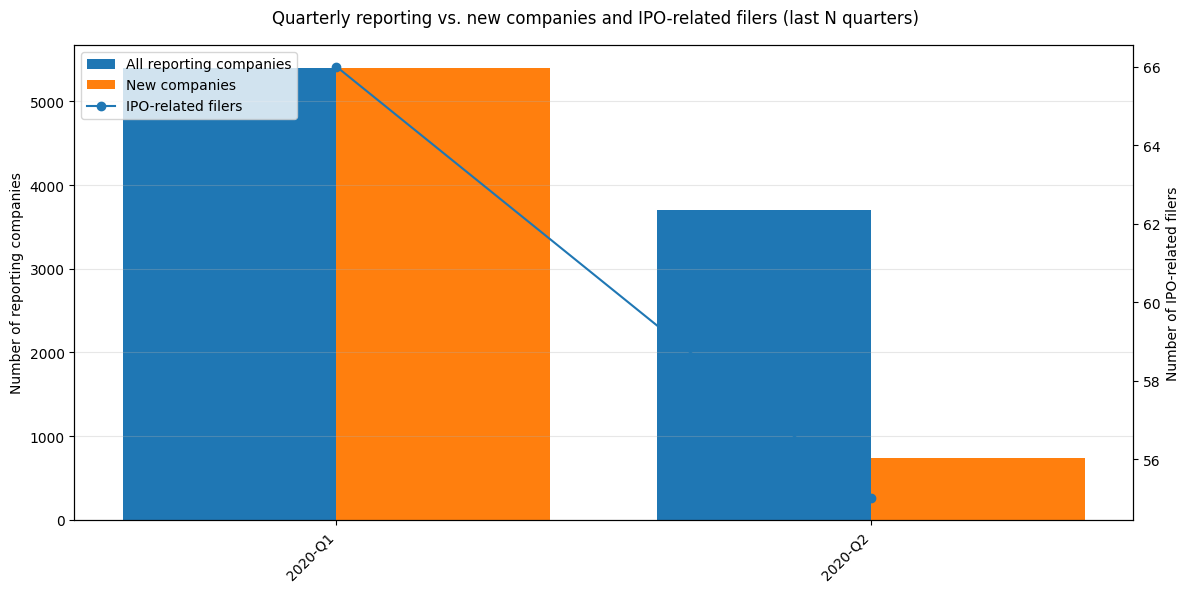

In [ ]:
from IPython.display import display

# Ensure inline display (keep this)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

# Collect results from prior RDD aggregations (keep your existing RDD code above this)
ipo_counts_list = ipo_counts.collect()
all_reporting_list = all_reporting_counts.collect()
new_counts_list = new_counts.collect()

# Sort by (year, quarter) like before
QUARTER_ORDER = {"q1": 1, "q2": 2, "q3": 3, "q4": 4}


def sort_key(item):
    (year, quarter), _ = item
    return (year, QUARTER_ORDER.get(quarter, 0))


ipo_sorted = sorted(ipo_counts_list, key=sort_key)
all_sorted = sorted(all_reporting_list, key=sort_key)
new_sorted = sorted(new_counts_list, key=sort_key)

labels = [f"{year}-{quarter.upper()}" for (year, quarter), _ in all_sorted]
all_vals = [count for _, count in all_sorted]
new_lookup = {k: v for k, v in new_sorted}
new_vals = [
    new_lookup.get((year, quarter), 0) for (year, quarter), _ in all_sorted
]
ipo_lookup = {k: v for k, v in ipo_sorted}
ipo_vals = [
    ipo_lookup.get((year, quarter), 0) for (year, quarter), _ in all_sorted
]

# ---- make the chart less cluttered: show only the last N quarters ----
N = 12  # try 8, 12, or 16 depending on how crowded it looks
labels_sub = labels[-N:]
all_vals_sub = all_vals[-N:]
new_vals_sub = new_vals[-N:]
ipo_vals_sub = ipo_vals[-N:]

x = range(len(labels_sub))

fig, ax1 = plt.subplots(figsize=(12, 6))

bar_width = 0.4

# Bars for all vs new companies on left y-axis
ax1.bar(
    [i - bar_width / 2 for i in x],
    all_vals_sub,
    width=bar_width,
    label="All reporting companies",
)
ax1.bar(
    [i + bar_width / 2 for i in x],
    new_vals_sub,
    width=bar_width,
    label="New companies",
)
ax1.set_ylabel("Number of reporting companies")
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels_sub, rotation=45, ha="right")
ax1.grid(axis="y", alpha=0.3)

# Line for IPO-related filers on right y-axis
ax2 = ax1.twinx()
ax2.plot(
    x, ipo_vals_sub, marker="o", linestyle="-", label="IPO-related filers"
)
ax2.set_ylabel("Number of IPO-related filers")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.suptitle(
    "Quarterly reporting vs. new companies and IPO-related filers (last N quarters)"
)
fig.tight_layout()

display(fig)
plt.close(fig)
